# Exploritory Data Analysis

In this notebook I will be exploring the data usedd in the 2025 data bowl and seeing how I could approach the problem of using pre-snap behavior to predict and better understand NFL team and player tendencies.

In [1]:
#read csv files

import pandas as pd
games = pd.read_csv('/Users/seanlee/Desktop/Github_repositories/Practice-repo/data/games.csv')
player_play = pd.read_csv('/Users/seanlee/Desktop/Github_repositories/Practice-repo/data/player_play.csv')
players = pd.read_csv('/Users/seanlee/Desktop/Github_repositories/Practice-repo/data/players.csv')
plays = pd.read_csv('/Users/seanlee/Desktop/Github_repositories/Practice-repo/data/plays.csv')


In [2]:
#games.csv info
display(games.shape,
    games.head(),
    games.describe(),
)
print(games.columns)

(136, 9)

,gameId,season,week,gameDate,gameTimeEastern,homeTeamAbbr,visitorTeamAbbr,homeFinalScore,visitorFinalScore
0,2022090800,2022,1,9/8/2022,20:20:00,LA,BUF,10,31
1,2022091100,2022,1,9/11/2022,13:00:00,ATL,NO,26,27
2,2022091101,2022,1,9/11/2022,13:00:00,CAR,CLE,24,26
3,2022091102,2022,1,9/11/2022,13:00:00,CHI,SF,19,10
4,2022091103,2022,1,9/11/2022,13:00:00,CIN,PIT,20,23


,gameId,season,week,homeFinalScore,visitorFinalScore
count,1.360000e+02,136.0,136.000000,136.000000,136.000000
mean,2.022099e+09,2022.0,4.845588,22.669118,20.948529
std,5.996614e+03,0.0,2.567254,8.659874,9.731446
min,2.022091e+09,2022.0,1.000000,3.000000,0.000000
25%,2.022093e+09,2022.0,3.000000,17.000000,14.750000
50%,2.022101e+09,2022.0,5.000000,22.500000,20.000000
75%,2.022102e+09,2022.0,7.000000,27.000000,27.000000
max,2.022111e+09,2022.0,9.000000,49.000000,48.000000


Index(['gameId', 'season', 'week', 'gameDate', 'gameTimeEastern',
       'homeTeamAbbr', 'visitorTeamAbbr', 'homeFinalScore',
       'visitorFinalScore'],
      dtype='str')


In [3]:
#player_play.csv info
display(player_play.shape,
    player_play.head(),
    player_play.describe(),
)
print(player_play.columns)

(354727, 50)

,gameId,playId,nflId,teamAbbr,hadRushAttempt,rushingYards,hadDropback,passingYards,sackYardsAsOffense,hadPassReception,...,wasRunningRoute,routeRan,blockedPlayerNFLId1,blockedPlayerNFLId2,blockedPlayerNFLId3,pressureAllowedAsBlocker,timeToPressureAllowedAsBlocker,pff_defensiveCoverageAssignment,pff_primaryDefensiveCoverageMatchupNflId,pff_secondaryDefensiveCoverageMatchupNflId
0,2022090800,56,35472,BUF,0,0,0,0,0,0,...,NaN,NaN,47917.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,2022090800,56,42392,BUF,0,0,0,0,0,0,...,NaN,NaN,47917.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2,2022090800,56,42489,BUF,0,0,0,0,0,1,...,1.0,IN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022090800,56,44875,BUF,0,0,0,0,0,0,...,NaN,NaN,43335.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
4,2022090800,56,44985,BUF,0,0,0,0,0,0,...,1.0,OUT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,gameId,playId,nflId,hadRushAttempt,rushingYards,hadDropback,passingYards,sackYardsAsOffense,hadPassReception,receivingYards,...,timeToPressureAsPassRusher,getOffTimeAsPassRusher,wasRunningRoute,blockedPlayerNFLId1,blockedPlayerNFLId2,blockedPlayerNFLId3,pressureAllowedAsBlocker,timeToPressureAllowedAsBlocker,pff_primaryDefensiveCoverageMatchupNflId,pff_secondaryDefensiveCoverageMatchupNflId
count,3.547270e+05,354727.000000,354727.000000,354727.000000,354727.000000,354727.000000,354727.000000,354727.000000,354727.000000,354727.000000,...,4328.000000,48032.000000,42779.0,49104.000000,4373.000000,7.000000,53044.000000,4080.000000,43484.000000,2387.000000
mean,2.022099e+09,2023.833091,47437.201033,0.019136,0.087304,0.017571,0.173268,-0.011471,0.015857,0.173373,...,2.866382,1.013016,1.0,46503.634694,49704.308027,49423.428571,0.076917,2.938971,47937.557078,47982.880184
std,5.979081e+03,1182.056487,5167.218156,0.137003,1.098183,0.131387,1.840473,0.309496,0.124923,1.841174,...,1.029087,0.298124,0.0,5105.945879,4056.385738,3275.463471,0.266463,0.989947,4696.183053,4603.065248
min,2.022091e+09,54.000000,25511.000000,0.000000,-10.000000,0.000000,-10.000000,-18.000000,0.000000,-11.000000,...,0.800000,0.004000,1.0,33131.000000,35454.000000,46269.000000,0.000000,0.800000,29550.000000,30842.000000
25%,2.022093e+09,996.000000,43426.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.200000,0.801000,1.0,43316.000000,46204.000000,47786.500000,0.000000,2.300000,44841.000000,44860.000000
50%,2.022101e+09,2017.000000,46457.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.700000,0.961000,1.0,46141.000000,48198.000000,47944.000000,0.000000,2.700000,47791.000000,46705.000000
75%,2.022102e+09,3022.000000,52590.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.225000,1.171000,1.0,52448.000000,53501.000000,50722.500000,0.000000,3.300000,52608.000000,52644.500000
max,2.022111e+09,5120.000000,55241.000000,1.000000,75.000000,1.000000,98.000000,0.000000,1.000000,98.000000,...,11.600000,2.000000,1.0,55241.000000,55239.000000,54733.000000,1.000000,11.600000,55168.000000,55157.000000


Index(['gameId', 'playId', 'nflId', 'teamAbbr', 'hadRushAttempt',
       'rushingYards', 'hadDropback', 'passingYards', 'sackYardsAsOffense',
       'hadPassReception', 'receivingYards', 'wasTargettedReceiver',
       'yardageGainedAfterTheCatch', 'fumbles', 'fumbleLost',
       'fumbleOutOfBounds', 'assistedTackle', 'forcedFumbleAsDefense',
       'halfSackYardsAsDefense', 'passDefensed', 'quarterbackHit',
       'sackYardsAsDefense', 'safetyAsDefense', 'soloTackle', 'tackleAssist',
       'tackleForALoss', 'tackleForALossYardage', 'hadInterception',
       'interceptionYards', 'fumbleRecoveries', 'fumbleRecoveryYards',
       'penaltyYards', 'penaltyNames', 'wasInitialPassRusher',
       'causedPressure', 'timeToPressureAsPassRusher',
       'getOffTimeAsPassRusher', 'inMotionAtBallSnap', 'shiftSinceLineset',
       'motionSinceLineset', 'wasRunningRoute', 'routeRan',
       'blockedPlayerNFLId1', 'blockedPlayerNFLId2', 'blockedPlayerNFLId3',
       'pressureAllowedAsBlocker', 'timeT

In [4]:
#players.csv info
display(players.shape,
    players.head(),
    players.describe(),
)
print(players.columns)

(1697, 7)

,nflId,height,weight,birthDate,collegeName,position,displayName
0,25511,6-4,225,1977-08-03,Michigan,QB,Tom Brady
1,29550,6-4,328,1982-01-22,Arkansas,T,Jason Peters
2,29851,6-2,225,1983-12-02,California,QB,Aaron Rodgers
3,30842,6-6,267,1984-05-19,UCLA,TE,Marcedes Lewis
4,33084,6-4,217,1985-05-17,Boston College,QB,Matt Ryan


,nflId,weight
count,1697.000000,1697.000000
mean,48237.157336,245.774308
std,5230.066814,47.256005
min,25511.000000,153.000000
25%,44830.000000,205.000000
50%,47874.000000,236.000000
75%,53476.000000,291.000000
max,55241.000000,380.000000


Index(['nflId', 'height', 'weight', 'birthDate', 'collegeName', 'position',
       'displayName'],
      dtype='str')


In [5]:
#plays.csv info
display(plays.shape,
    plays.head(),
    plays.describe(),
)
print(plays.columns)

(16124, 50)

,gameId,playId,playDescription,quarter,down,yardsToGo,possessionTeam,defensiveTeam,yardlineSide,yardlineNumber,...,yardsGained,homeTeamWinProbabilityAdded,visitorTeamWinProbilityAdded,expectedPointsAdded,isDropback,pff_runConceptPrimary,pff_runConceptSecondary,pff_runPassOption,pff_passCoverage,pff_manZone
0,2022102302,2655,(1:54) (Shotgun) J.Burrow pass short middle to...,3,1,10,CIN,ATL,CIN,21,...,9,0.004634,-0.004634,0.702717,True,NaN,NaN,0,Cover-3,Zone
1,2022091809,3698,(2:13) (Shotgun) J.Burrow pass short right to ...,4,1,10,CIN,DAL,CIN,8,...,4,0.002847,-0.002847,-0.240509,True,NaN,NaN,0,Quarters,Zone
2,2022103004,3146,(2:00) (Shotgun) D.Mills pass short right to D...,4,3,12,HOU,TEN,HOU,20,...,6,0.000205,-0.000205,-0.218480,True,NaN,NaN,0,Quarters,Zone
3,2022110610,348,(9:28) (Shotgun) P.Mahomes pass short left to ...,1,2,10,KC,TEN,TEN,23,...,4,-0.001308,0.001308,-0.427749,True,NaN,NaN,0,Quarters,Zone
4,2022102700,2799,(2:16) (Shotgun) L.Jackson up the middle to TB...,3,2,8,BAL,TB,TB,27,...,-1,0.027141,-0.027141,-0.638912,False,MAN,READ OPTION,0,Cover-1,Man


,gameId,playId,quarter,down,yardsToGo,yardlineNumber,preSnapHomeScore,preSnapVisitorScore,absoluteYardlineNumber,preSnapHomeTeamWinProbability,...,timeInTackleBox,timeToSack,qbKneel,penaltyYards,prePenaltyYardsGained,yardsGained,homeTeamWinProbabilityAdded,visitorTeamWinProbilityAdded,expectedPointsAdded,pff_runPassOption
count,1.612400e+04,16124.000000,16124.000000,16124.000000,16124.000000,16124.000000,16124.000000,16124.000000,16124.000000,16124.000000,...,8917.000000,608.000000,16124.000000,384.000000,16124.000000,16124.000000,16124.000000,16124.000000,16124.000000,16124.000000
mean,2.022099e+09,2023.830563,2.572253,1.800794,8.461300,29.226185,11.255830,10.049615,60.413483,0.552007,...,2.632755,4.515796,0.010233,1.333333,5.475254,5.460618,-0.000065,0.000065,-0.029381,0.101340
std,5.979252e+03,1182.090771,1.135404,0.827194,3.908658,12.662828,9.468489,9.224680,24.326003,0.290603,...,0.817805,1.314407,0.100643,8.785422,8.622005,8.833095,0.041561,0.041561,1.397405,0.301787
min,2.022091e+09,54.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,11.000000,0.001049,...,0.000000,2.135000,0.000000,-20.000000,-18.000000,-68.000000,-0.834887,-0.541161,-13.023600,0.000000
25%,2.022093e+09,996.000000,2.000000,1.000000,6.000000,21.000000,3.000000,0.000000,40.000000,0.324613,...,2.079000,3.643750,0.000000,0.000000,0.000000,0.000000,-0.012808,-0.013166,-0.645440,0.000000
50%,2.022101e+09,2017.000000,3.000000,2.000000,10.000000,30.000000,10.000000,7.000000,61.000000,0.578922,...,2.569000,4.249000,0.000000,0.000000,3.000000,3.000000,0.000000,0.000000,-0.178783,0.000000
75%,2.022102e+09,3022.000000,4.000000,2.000000,10.000000,40.000000,17.000000,16.000000,81.000000,0.791601,...,3.100000,5.139000,0.000000,5.000000,8.000000,8.000000,0.013166,0.012808,0.696452,0.000000
max,2.022111e+09,5120.000000,5.000000,4.000000,38.000000,50.000000,49.000000,48.000000,109.000000,0.999197,...,7.400000,11.912000,1.000000,15.000000,98.000000,98.000000,0.541161,0.834887,8.698986,1.000000


Index(['gameId', 'playId', 'playDescription', 'quarter', 'down', 'yardsToGo',
       'possessionTeam', 'defensiveTeam', 'yardlineSide', 'yardlineNumber',
       'gameClock', 'preSnapHomeScore', 'preSnapVisitorScore',
       'playNullifiedByPenalty', 'absoluteYardlineNumber',
       'preSnapHomeTeamWinProbability', 'preSnapVisitorTeamWinProbability',
       'expectedPoints', 'offenseFormation', 'receiverAlignment',
       'playClockAtSnap', 'passResult', 'passLength', 'targetX', 'targetY',
       'playAction', 'dropbackType', 'dropbackDistance', 'passLocationType',
       'timeToThrow', 'timeInTackleBox', 'timeToSack', 'passTippedAtLine',
       'unblockedPressure', 'qbSpike', 'qbKneel', 'qbSneak',
       'rushLocationType', 'penaltyYards', 'prePenaltyYardsGained',
       'yardsGained', 'homeTeamWinProbabilityAdded',
       'visitorTeamWinProbilityAdded', 'expectedPointsAdded', 'isDropback',
       'pff_runConceptPrimary', 'pff_runConceptSecondary', 'pff_runPassOption',
       'pff_pass

In [6]:
print(plays.playDescription)

0        (1:54) (Shotgun) J.Burrow pass short middle to...
1        (2:13) (Shotgun) J.Burrow pass short right to ...
2        (2:00) (Shotgun) D.Mills pass short right to D...
3        (9:28) (Shotgun) P.Mahomes pass short left to ...
4        (2:16) (Shotgun) L.Jackson up the middle to TB...
                               ...                        
16119    (12:49) (Shotgun) T.Lawrence pass incomplete s...
16120    (12:32) (Shotgun) K.Cousins pass incomplete de...
16121    (9:59) (Shotgun) P.Mahomes scrambles right end...
16122    (:45) C.Rush pass incomplete deep right to C.L...
16123    (15:00) Br.Hall up the middle for 34 yards, TO...
Name: playDescription, Length: 16124, dtype: str


In [7]:
#pick a random play from tracking week 1
tracking_week1 = pd.read_csv('/Users/seanlee/Desktop/Github_repositories/Practice-repo/data/tracking_week_1.csv')

game_id, play_id = tracking_week1[['gameId', 'playId']].drop_duplicates().sample(1).iloc[0]

def get_play(tracking_df, game_id, play_id):
    play_df = tracking_df[
        (tracking_df['gameId'] == game_id) &
        (tracking_df['playId'] == play_id)
    ]
    return game_id, play_id, play_df


def get_random_play(tracking_df):
    game_id, play_id = tracking_df[['gameId', 'playId']].drop_duplicates().sample(1).iloc[0]
    return get_play(tracking_df, game_id, play_id)


game_id, play_id, one_play = get_random_play(tracking_week1)
one_play

,gameId,playId,nflId,displayName,frameId,frameType,time,jerseyNumber,club,playDirection,x,y,s,a,dis,o,dir,event
3662773,2022091106,2743,35466.0,Devin McCourty,1,BEFORE_SNAP,2022-09-11 19:15:37.7,32.0,NE,right,27.470000,24.89,0.76,0.28,0.08,272.30,100.53,huddle_break_offense
3662774,2022091106,2743,35466.0,Devin McCourty,2,BEFORE_SNAP,2022-09-11 19:15:37.8,32.0,NE,right,27.550000,24.87,0.79,0.28,0.08,270.11,105.67,NaN
3662775,2022091106,2743,35466.0,Devin McCourty,3,BEFORE_SNAP,2022-09-11 19:15:37.9,32.0,NE,right,27.630000,24.84,0.81,0.34,0.08,267.15,110.78,NaN
3662776,2022091106,2743,35466.0,Devin McCourty,4,BEFORE_SNAP,2022-09-11 19:15:38,32.0,NE,right,27.710000,24.80,0.85,0.32,0.09,264.57,113.26,NaN
3662777,2022091106,2743,35466.0,Devin McCourty,5,BEFORE_SNAP,2022-09-11 19:15:38.1,32.0,NE,right,27.790000,24.78,0.82,0.04,0.08,261.98,108.68,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3666494,2022091106,2743,NaN,football,158,AFTER_SNAP,2022-09-11 19:15:53.4,NaN,football,right,28.879999,0.51,6.01,2.29,0.60,NaN,NaN,out_of_bounds
3666495,2022091106,2743,NaN,football,159,AFTER_SNAP,2022-09-11 19:15:53.5,NaN,football,right,29.410000,0.23,5.89,2.16,0.60,NaN,NaN,NaN
3666496,2022091106,2743,NaN,football,160,AFTER_SNAP,2022-09-11 19:15:53.6,NaN,football,right,29.950001,-0.02,5.85,1.91,0.59,NaN,NaN,NaN
3666497,2022091106,2743,NaN,football,161,AFTER_SNAP,2022-09-11 19:15:53.7,NaN,football,right,30.469999,-0.26,5.64,2.10,0.57,NaN,NaN,NaN


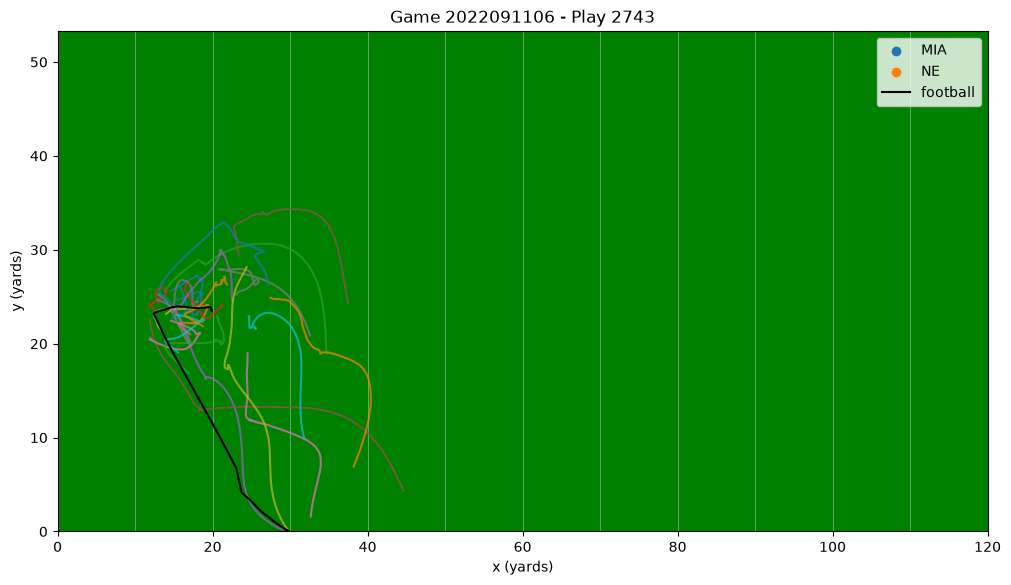

In [8]:
import matplotlib.pyplot as plt

def plot_play(play_df, game_id, play_id):
    fig, ax = plt.subplots(figsize=(12, 6.5))

    # field background
    ax.set_facecolor('green')
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 53.3)
    for yard in range(10, 111, 10):
        ax.axvline(yard, color='white', linewidth=0.5, alpha=0.5)

    # plot each player's path, football separately
    for club, group in play_df.groupby('club'):
        if club == 'football':
            ax.plot(group['x'], group['y'], color='black', label='football')
        else:
            for nfl_id, player_group in group.groupby('nflId'):
                ax.plot(player_group['x'], player_group['y'], alpha=0.7)
            ax.scatter([], [], label=club)

    ax.legend(loc='upper right')
    ax.set_title(f"Game {game_id} - Play {play_id}")
    ax.set_xlabel('x (yards)')
    ax.set_ylabel('y (yards)')
    plt.show()

plot_play(one_play, game_id, play_id)

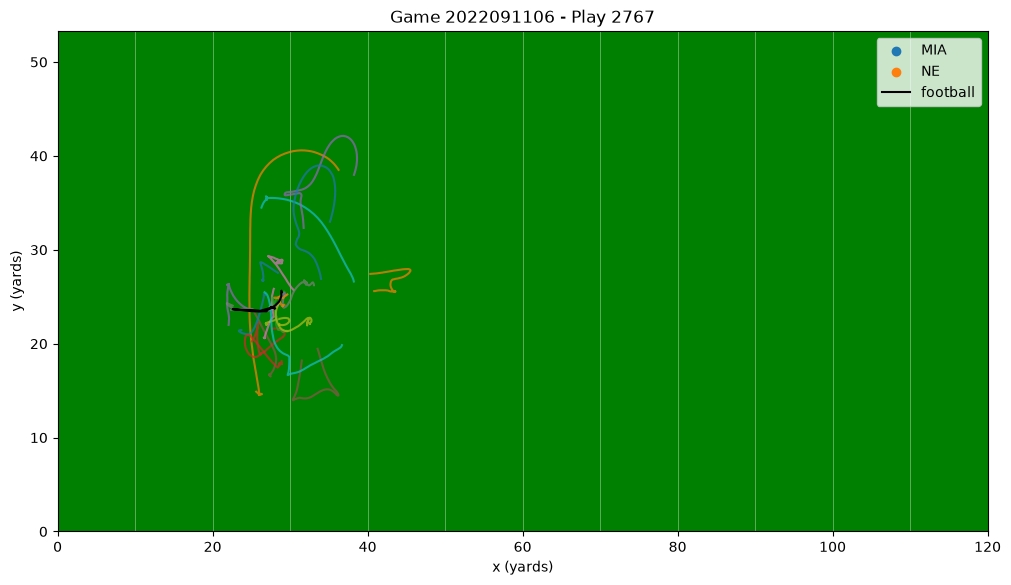

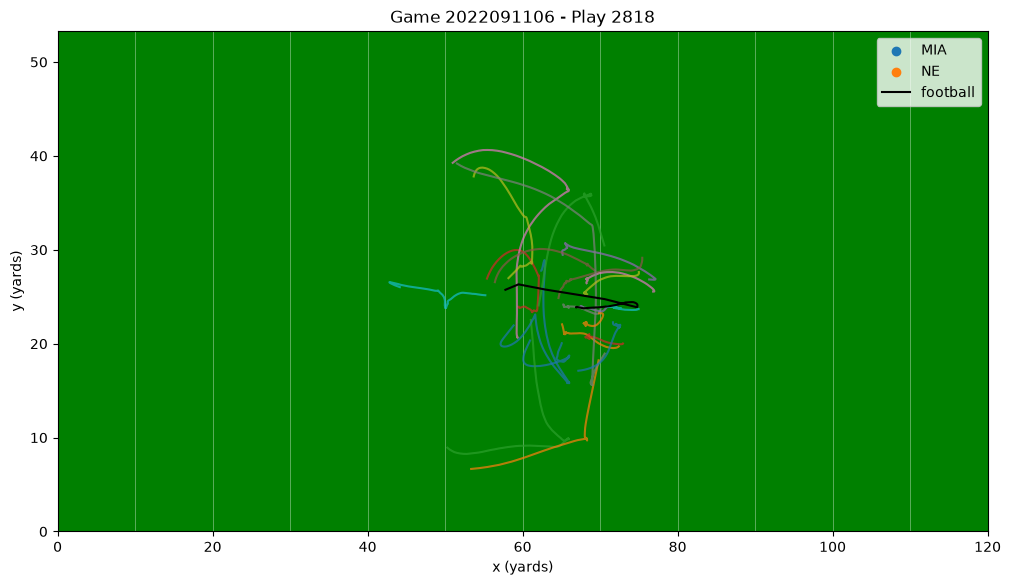

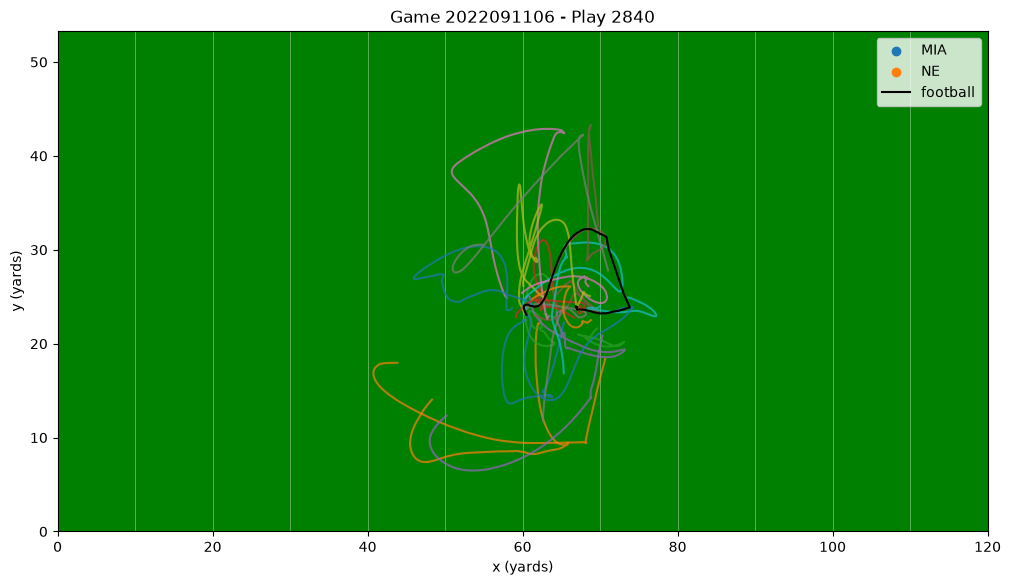

In [9]:
#visualise the next few consecutive plays in the same game
n_plays = 3

game_play_ids = sorted(tracking_week1.loc[tracking_week1['gameId'] == game_id, 'playId'].unique())
start_index = game_play_ids.index(play_id)
next_play_ids = game_play_ids[start_index + 1: start_index + 1 + n_plays]

for next_play_id in next_play_ids:
    next_play_df = tracking_week1[
        (tracking_week1['gameId'] == game_id) &
        (tracking_week1['playId'] == next_play_id)
    ]
    plot_play(next_play_df, game_id, next_play_id)

# Some findings

- Personel Movement
- DOwn and distance
- Offensive and defensice pre snap formations
- Team tendecies
- What percentage of plays are run/pass
- Distance between defenders and WRs 
- How often each defense sets up in what
- What kind of throws each QB uses the most
- What route the WR prefer
